# ADRMiner — Topic Modeling with BERTopic

## Purpose

This notebook implements the topic-modeling stage of the **ADRMiner** workflow. It uses
[BERTopic](https://maartengr.github.io/BERTopic/) to discover recurring concerns in a
corpus of Architecture Decision Records (ADRs), inspect the resulting topics, compute
topic-quality metrics, and assign a dominant topic to each ADR.

The notebook supports the results reported for **RQ1** in the companion paper,
*“A Text Mining and Classification Approach for Analyzing Architecture Decision
Records.”*

## Main inputs

- `../data/LLM4ADR-adrs__adrs_english.pickle`: curated ADR corpus.
- `saved_topicmodel/`: persisted BERTopic model and topic metadata.
- `../sample/kruchten_gt_processed1.csv`: manually annotated ADR sample used in
  complementary analyses.

## Main outputs

- Topic labels, frequencies, maps, hierarchies, and word clouds.
- Topic coherence and diversity values.
- Topic predictions for the annotated sample.
- `../results/all_projects-topics.json`: dominant-topic assignments for the complete
  curated corpus.

## Recommended execution mode

The default workflow **loads the persisted topic model** from `saved_topicmodel/`.
This is the fastest and most reproducible way to inspect the reported results.
Instructions for rebuilding the model are provided below, but retraining may take longer
and may require an OpenAI API key when OpenAI-based topic representations are enabled.

> **Path assumption:** Run this notebook from the `notebooks/` directory. Most data
> and result paths are resolved relative to that location.

## 1. Environment setup

The following cells import the data-science dependencies and ADRMiner modules used
throughout the notebook. The local modules must be available in the same directory as
this notebook.

In [1]:
import pickle
import pandas as pd
import json
from tqdm import tqdm
import numpy as np
import os
import sys
from IPython.display import display, Markdown
import logging
from pythonjsonlogger.json import JsonFormatter
import matplotlib.pyplot as plt

from typing import Dict, List


In [2]:
from adr import adr
import utils
from adr_topic_mining import ADRTopicModel

### 1.1 Optional OpenAI configuration

Environment variables are loaded from a `.env` file in the repository root. They are
needed when rebuilding topic representations with OpenAI models. Loading the persisted
BERTopic model and inspecting its existing labels may not require new API calls.

Expected variables include:

```text
OPENAI_API_KEY=...
OPENAI_MODEL_NAME=...
OPENAI_EMBEDDINGS_MODEL=...
```

Avoid committing API keys to the repository.

In [3]:
from dotenv import load_dotenv

# Load optional model and API configuration from a local .env file.
# These variables are required only for stages that invoke OpenAI services.
print(load_dotenv())

os.environ["OPENAI_API_KEY"] = os.getenv("OPENAI_API_KEY",'')
os.environ["OPENAI_MODEL_NAME"] = os.getenv("OPENAI_MODEL_NAME",'')
os.environ["EMBEDDINGS_MODEL"] = os.getenv("OPENAI_EMBEDDINGS_MODEL",'')
os.environ["TOKENIZERS_PARALLELISM"] = "false"

print("OpenAI model:", os.environ["OPENAI_MODEL_NAME"])
print("Embedding model:", os.environ["EMBEDDINGS_MODEL"])

True
OpenAI model: 
Embedding model: 


### 1.2 Input and output paths

This cell defines the curated ADR dataset and the directory containing the persisted
topic model. Adjust these paths when analyzing another dataset or running the notebook
from a different working directory.

In [4]:
# Curated English-language ADR dataset used in the companion study.
# The pickle file is organized as organization -> project -> ADR documents.
ENGLISH_DATAPATH = './data/LLM4ADR-adrs__adrs_english.pickle'

# Persisted BERTopic model and its topic-level metadata.
TOPICS_FOLDER = "saved_topicmodel"
TOPICS_DATAFRAME = os.path.join(TOPICS_FOLDER, 'topics_dataframe.csv')

### 1.3 Result caching and recomputation

Several inference stages save their results to JSON files. By default, the notebook
reuses an existing result file instead of repeating the computation.

Set `FORCE_RECOMPUTE = True` to rerun those stages and overwrite their cached results.
Keep it set to `False` for the faster and less costly reproduction path.

> Enabling this flag reruns inference rather than merely rewriting the file. For
> API-dependent stages, forced recomputation may increase runtime and cost.


In [5]:
# Global result-caching policy.
#
# False: reuse existing result files and skip the corresponding inference.
# True:  rerun inference and overwrite existing result files.
FORCE_RECOMPUTE = False

print("Force recomputation:", FORCE_RECOMPUTE)


Force recomputation: False


---

## 2. Load and filter the ADR corpus

The dataset is organized hierarchically by organization, project, and ADR. We reproduce
the study's inclusion criteria by retaining projects with at least five ADRs and an
average ADR length of at least 500 characters. The resulting document list is the corpus
used by BERTopic.

In [6]:
# Resolve the dataset path relative to the notebooks/ directory.
relative_path = os.path.join('..', ENGLISH_DATAPATH)
with open(relative_path, 'rb') as file:
    dict_adrs = pickle.load(file)

print(len(dict_adrs), "top-level organizations/projects loaded")

547 top-level organizations/projects loaded


In [7]:
def count_adrs(projects):
    # Count ADR files belonging to a sequence of (organization, project) pairs.
    count_adrs = 0
    for org, project in projects:
        adrs = dict_adrs[org][project]
        count_adrs += len(adrs)
    return count_adrs


# Reproduce the project-level inclusion criteria used in the study.
projects_dict = utils.process_projects(
    dict_adrs,
    min_adrs_per_project=5,
    min_adr_length=500,
)
valid_projects = projects_dict['valid_projects']

print("Total number of ADRs:", count_adrs(projects_dict['all_projects']))
print("Total number of ADRs in valid projects:", count_adrs(valid_projects))

organizations:   0%|          | 0/547 [00:00<?, ?it/s]

Total number of ADRs: 6061
Total number of ADRs in valid projects: 4316


In [8]:
def get_text_column(df_texts, column='original_text'):
    # Return a dataframe text column as a list of document strings.
    values = df_texts[column]
    if isinstance(values.values[0], str):
        return values.values.tolist()
    return [' '.join(value) for value in values]


def get_adr_texts(adrs_dict):
    # Flatten a hierarchical ADR dictionary into a list of ADR documents.
    texts = []
    for org in adrs_dict.keys():
        for project in adrs_dict[org].keys():
            texts.extend(list(adrs_dict[org][project].values()))
    return texts


# Build the cleaned textual corpus used for topic modeling.
docs = utils.get_documents(
    valid_projects,
    dict_adrs,
    verbose=False,
    field='content',
)
print("Number of cleaned ADR documents:", len(docs))

Number of cleaned ADR documents: 4316


## 3. Initialize the ADR topic-model wrapper

`ADRTopicModel` encapsulates corpus preparation, BERTopic training and loading,
prediction, visualization, persistence, and topic-quality metrics.

In [9]:
adr_topic_model = ADRTopicModel()

## 4. Load or rebuild the topic model

### Default: load the persisted model

The default cell loads the model distributed with the artifact. This supports rapid
inspection and reproduction of the reported topic results.

### Optional: rebuild from the corpus

To train a new model, uncomment the `prepare_corpus` and `build` calls. Rebuilding may
produce slightly different clusters depending on library versions and stochastic
components. When `use_openai=True`, topic-label generation also requires an OpenAI API
key and may incur API costs.

## 4. Topic model

In [10]:
# DEFAULT REPRODUCTION MODE:
# Load the persisted model distributed with the artifact.
adr_topic_model.load(TOPICS_FOLDER)

,Topic,Count,Name,CustomName,Representation,OpenAI,Representative_Docs
0,-1,1514,-1_aws_deployment_cloud_services,Cloud Infrastructure and Deployment Decision-M...,"[aws, deployment, cloud, services, platform, s...",[Cloud Infrastructure and Deployment Decision-...,NaN
1,0,407,0_publishing_database_metadata_api,Software Architecture Decisions and Data Persi...,"[publishing, database, metadata, api, db, stor...",[Software Architecture Decisions and Data Pers...,NaN
2,1,257,1_fxa_jsx_framework_styles,Frontend architecture and UI component redesign,"[fxa, jsx, framework, styles, react, webpack, ...",[Frontend architecture and UI component redesign],NaN
3,2,213,2_architecture_decision_record_adrs_adr_archit...,Architectural Decision Records (ADR) Generatio...,"[architecture_decision_record, adrs, adr, arch...",[Architectural Decision Records (ADR) Generati...,NaN
4,3,109,3_kubernetes_kubectl_pods_pod,Kubernetes ingress and resource management str...,"[kubernetes, kubectl, pods, pod, ingress, aws,...",[Kubernetes ingress and resource management st...,NaN
...,...,...,...,...,...,...,...
68,67,12,67_microservices_microservice_monolithic_services,Software Architecture Decisions and Frameworks,"[microservices, microservice, monolithic, serv...",[Software Architecture Decisions and Frameworks],NaN
69,68,12,68_protocol_secrecy_otr_otrv4,Secure messaging protocols with key exchange a...,"[protocol, secrecy, otr, otrv4, otrv3, rfc, en...",[Secure messaging protocols with key exchange ...,NaN
70,69,11,69_domains_app_domain_internalrootdomain_dns,Internal DNS and Domain Management for Cloud P...,"[domains, app_domain, internalrootdomain, dns,...",[Internal DNS and Domain Management for Cloud ...,NaN
71,70,11,70_blobstore_blobstodelete_storage_blobs,Blob storage optimization and deduplication st...,"[blobstore, blobstodelete, storage, blobs, sto...",[Blob storage optimization and deduplication s...,NaN


In [11]:
# OPTIONAL TRAINING MODE:
# Uncomment these lines to rebuild the topic model from the cleaned corpus.
# When use_openai=True, OpenAI produces an additional topic representation.
# Using OpenAI may incur API costs. Set use_openai=False to rebuild the topic model without the OpenAI-based representation.
# With use_openai=False, BERTopic generates topic representations and labels
# from c-TF-IDF keywords.

# adr_topic_model.prepare_corpus(docs)
# adr_topic_model.build(use_openai=True)

In [12]:
# OPTIONAL: persist a newly trained model for later reuse.
# Do not run this cell unless the model was rebuilt in the previous step.

# adr_topic_model.persist(TOPICS_FOLDER)

### 4.1 Inspect topic labels and the topic map

ADRMiner stores both keyword-oriented topic representations and, when available,
OpenAI-generated descriptive labels. The following cells inspect both representations
and display the topic map.

In [13]:
# List the keyword-oriented topic labels generated through KeyBERT.
adr_topic_model.get_topic_labels()

['-1_aws_deployment_cloud_services',
 '0_publishing_database_metadata_api',
 '1_fxa_jsx_framework_styles',
 '2_architecture_decision_record_adrs_adr_architectural',
 '3_kubernetes_kubectl_pods_pod',
 '4_branches_releases_branching_branch',
 '5_docker_dockerfiles_dockerfile_containers',
 '6_apis_api_swagger_openapi',
 '7_testcontainers_testing_tests_testharness',
 '8_evidence_attacks_validators_consensus',
 '9_cosmos_sdk_protobuf_compatibility',
 '10_authentication_oauth2_authenticate_oauth',
 '11_aws_s3_uploading_uploads',
 '12_plugins_plugin_elektra_global',
 '13_python_pip_versions_py',
 '14_elasticsearch_lucene_searches_searching',
 '15_wikibaseclient_wikibaselexeme_wikibaserepo_wikibase',
 '16_secrets_kubernetes_vault_encrypt',
 '17_eclipse_xml_epl_java',
 '18_cassandramessageidmapper_cassandramessagemapper_imapuidtable_messageidtable',
 '19_authnrequests_authnrequest_saml_saml2',
 '20_frontend_webjars_hmrc_webjar',
 '21_attribute_specification_describes_decisions',
 '22_logging_lo

In [14]:
# List the descriptive OpenAI topic labels, when available.
adr_topic_model.get_topic_labels(representation='OpenAI')

['Cloud Infrastructure and Deployment Decision-Making',
 'Software Architecture Decisions and Data Persistence',
 'Frontend architecture and UI component redesign',
 'Architectural Decision Records (ADR) Generation and Documentation',
 'Kubernetes ingress and resource management strategies',
 'Software Release Management and Branching Strategies',
 'Containerized CI/CD workflows and deployment processes',
 'API Design, Versioning, and Specification Management',
 'Software Testing Strategies and Database Handling',
 'Blockchain Evidence and Consensus Mechanisms',
 'Cosmos SDK Module Interactions and Encoding Strategies',
 'User Authentication and Authorization Mechanisms',
 'AWS S3-Based File Uploads and Access Control',
 'Elektra Plugin Architecture and Customization Strategies',
 'Python version support and migration strategies',
 'Advanced Search Architecture and Indexing Strategies',
 'Wikibase Architecture, Releases, Security, and Maintenance',
 'Secrets management and secure confi

Batches:   0%|          | 0/135 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

Resetting positions to accord with alignment


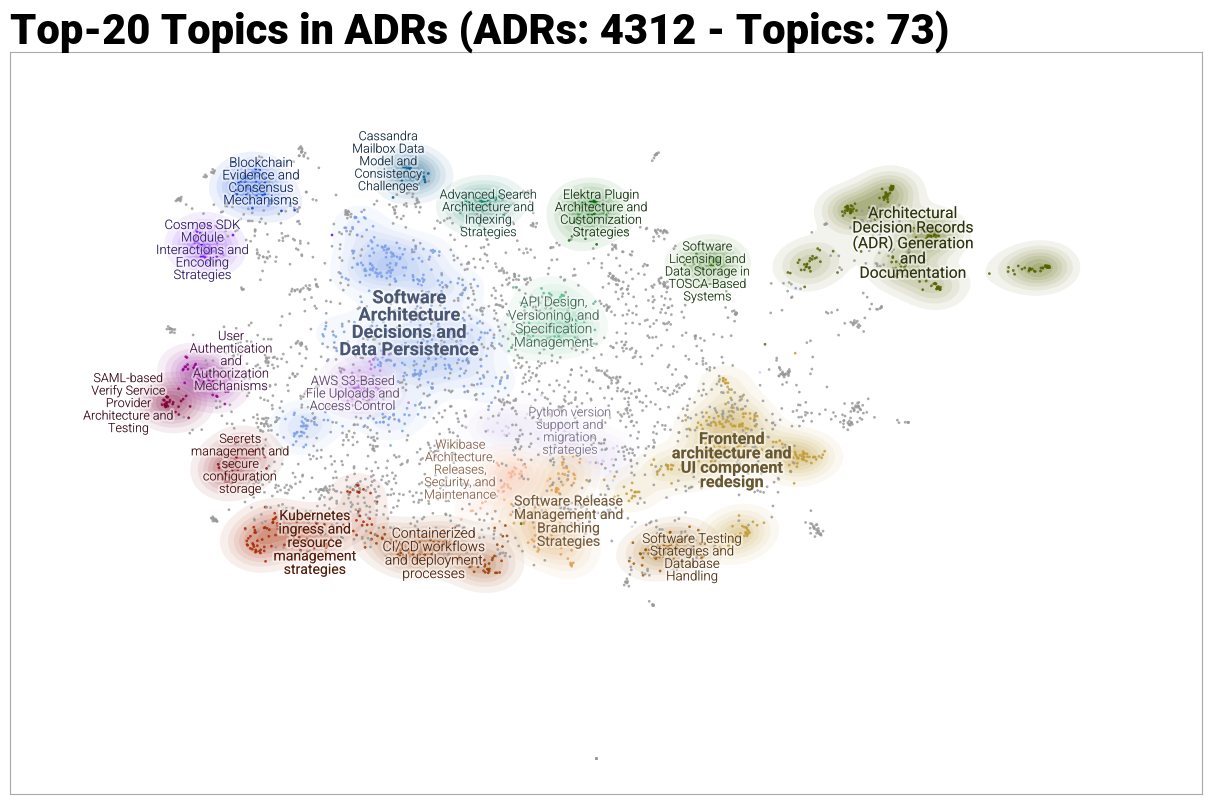

In [15]:
# Display topic identifiers, labels, representations, and frequencies.
adr_topic_model.show_topic_map()

## 5. Predict topics for individual ADRs and projects

These examples illustrate how to apply the loaded model to unseen ADR text. The first
cell predicts a topic for a single ADR; the following cells classify all ADRs belonging
to one organization/project pair.

These demonstration cells are not required to regenerate the aggregate study results.

In [16]:
# Demonstration: predict the dominant topic for one ADR document
new_doc = """Date: 2017-07-25 Accepted Verify have a number of pre-existing (closed source) libraries at various levels of abstraction for handling SAML behaviour. By depending on these we can benefit from all the work that's already been done making these easy to use and secure by default. There's a plan in the medium term to open source a lot of these libraries. By depending on as few of them as possible we should be able to call the verify-service-provider "fully open" sooner. Some of the libraries at higher levels of abstraction are of questionable value - although they make it easy to be consistent with the rest of verify they abstract away the exact nature of the SAML which makes the code hard to read. Good libraries that we should use for now: saml-serialisers ida-saml-extensions saml-security saml-metadata-bindings Libraries we think we should ignore hub-saml We may have to inline some bits of e.g. hub-saml, or reimplement them differently.""" 

adr_topic_model.predict(new_doc, multiple_topics=False)

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

2026-06-20 09:00:01,863 - BERTopic - Predicting topic assignments through cosine similarity of topic and document embeddings.


{'text': 'Date: 2017-07-25 Accepted Verify have a number of pre-existing (closed source) libraries at various levels of abstraction for handling SAML behaviour. By depending on these we can benefit from all the work that\'s already been done making these easy to use and secure by default. There\'s a plan in the medium term to open source a lot of these libraries. By depending on as few of them as possible we should be able to call the verify-service-provider "fully open" sooner. Some of the libraries at higher levels of abstraction are of questionable value - although they make it easy to be consistent with the rest of verify they abstract away the exact nature of the SAML which makes the code hard to read. Good libraries that we should use for now: saml-serialisers ida-saml-extensions saml-security saml-metadata-bindings Libraries we think we should ignore hub-saml We may have to inline some bits of e.g. hub-saml, or reimplement them differently.',
 'topics': [19],
 'keywords': [['aut

In [17]:
# Load all ADRs from one example organization/project pair
adrs_to_classify = utils.get_documents_by_key(('LBHackney-IT', 'remultiform'), dict_adrs, field='raw')
adrs_to_classify

{'0001-record-architecture-decisions.md': "# 1. Record architecture decisions\n\nDate: 2019-10-29\n\n## Status\n\nAccepted\n\n## Context\n\nWe need to record the architectural decisions made on this project.\n\n## Decision\n\nWe will use Architecture Decision Records, as\n[described by Michael Nygard](http://thinkrelevance.com/blog/2011/11/15/documenting-architecture-decisions).\n\n## Consequences\n\nSee Michael Nygard's article, linked above. For a lightweight ADR toolset, see\nNat Pryce's [adr-tools](https://github.com/npryce/adr-tools).\n",
 '0002-use-typescript.md': "# 2. Use TypeScript\n\nDate: 2019-10-29\n\n## Status\n\nAccepted\n\n## Context\n\nWe want to be confident about the code we write, and for it to be\nself-documenting as much as possible.\n[TypeScript](https://www.typescriptlang.org/) is a compiled language with\noptional typing. It's a superset of JavaScript, so is familiar to developers who\nknow JavaScript. It has wide editor support.\n\nAs of writing, TypeScript is 

In [18]:
# Demonstration: predict the dominant topic for a batch of ADRs
adr_topic_model.predict_batch(adrs_to_classify, organization='LBHackney-IT', project='remultiform', multiple_topics=False)

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

2026-06-20 09:00:01,999 - BERTopic - Predicting topic assignments through cosine similarity of topic and document embeddings.
Inferring topics for ADRs: 10it [00:00, ?it/s]


[{'text': "# 1. Record architecture decisions\n\nDate: 2019-10-29\n\n## Status\n\nAccepted\n\n## Context\n\nWe need to record the architectural decisions made on this project.\n\n## Decision\n\nWe will use Architecture Decision Records, as\n[described by Michael Nygard](http://thinkrelevance.com/blog/2011/11/15/documenting-architecture-decisions).\n\n## Consequences\n\nSee Michael Nygard's article, linked above. For a lightweight ADR toolset, see\nNat Pryce's [adr-tools](https://github.com/npryce/adr-tools).\n",
  'topics': [2],
  'keywords': [['architecture_decision_record',
    'adrs',
    'adr',
    'architectural',
    'architecture',
    'documenting',
    'documentation',
    'tools',
    'describes',
    'record']],
  'keybert_representation': ['1_fxa_jsx_framework_styles'],
  'openai_representation': ['Frontend architecture and UI component redesign'],
  'probabilities': [0.9443061351776123],
  'metadata': {'organization': 'LBHackney-IT',
   'project': 'remultiform',
   'adr_ke

---

## 6. Assign topics to the manually annotated sample

This optional stage applies the topic model to the ADRs in the manually annotated
Kruchten sample. It illustrates how topic assignments can be connected with the
taxonomy-based analyses. Results are cached as JSON to avoid repeating inference.

### Annotated-sample topic assignment

In [19]:
KRUCHTEN_GROUND_TRUTH = './sample/kruchten_gt_processed1.csv'

# Load the manually annotated sample used for calibration and evaluation.
relative_path = os.path.join('..', KRUCHTEN_GROUND_TRUTH)
df_gt = pd.read_csv(relative_path, sep=';').dropna(
    subset=['text', 'human', 'ADR', 'raw_text']
)
print("Ground-truth shape:", df_gt.shape)

# Inspect category coverage in the human and model-generated labels.
print("Human categories:", len(df_gt['human'].unique()), df_gt['human'].unique())
print(
    "Predicted categories:",
    len(df_gt['primary_category'].unique()),
    df_gt['primary_category'].unique(),
)

# Map ADR identifiers to their raw text for batch topic prediction.
adr_texts = {row['ADR']: row['raw_text'] for _, row in df_gt.iterrows()}
df_gt.head()

Ground-truth shape: (200, 9)
Human categories: 4 ['Existence (ontocrisis)' 'Executive (pericrisis)' 'Property (diacrisis)'
 'Ban/Non-Existence (anticrisis)']
Predicted categories: 4 ['Existence (ontocrisis)' 'Property (diacrisis)' 'Executive (pericrisis)'
 'Ban/Non-Existence (anticrisis)']


,text,ADR,Organization-Project,primary_category,explanation,max_confidence_value,human,Agreement,raw_text
0,'adr 3: connecting the store to a component pw...,adr-003-store-connector-container-component.md,"('AYCHAIN', 'AYCHAIN.github.io')",Existence (ontocrisis),The ADR describes the implementation of a conn...,"0,85",Existence (ontocrisis),1.0,# ADR 3: Connecting the store to a component\n...
1,'4. compute provisioning through ansible Accep...,adr-004.md,"('Abelaa', 'pcmt')",Existence (ontocrisis),The ADR describes a decision to implement prov...,"0,85",Existence (ontocrisis),1.0,# 4. Compute Provisioning through Ansible\n\n#...
2,"'7. versioning and release mechanism Accepted,...",adr-007.md,"('Abelaa', 'pcmt')",Property (diacrisis),The ADR primarily discusses versioning strateg...,"0,80",Executive (pericrisis),0.0,# 7. Versioning and Release Mechanism\n\n## St...
3,"'3. for config, prefer prefix over nesting and...",0003-for-config-prefer-prefix-over-nesting-and...,"('Accenture', 'reactive-interaction-gateway')",Existence (ontocrisis),The ADR primarily discusses decisions related ...,"0,85",Existence (ontocrisis),1.0,"# 3. For config, prefer prefix over nesting an..."
4,'cutting release branch does not create a set ...,005-cutting-release-branch.md,"('Accenture', 'sfpowerscripts')",Executive (pericrisis),The ADR discusses a process and policy change ...,"0,90",Executive (pericrisis),1.0,# Cutting release branch does not create a set...


The following cell predicts one dominant topic for each ADR in the annotated sample and saves the results only when the cache does not already exist.

In [20]:
# Reduce logging noise during batch inference.
logging.getLogger('adr_topic_miner').setLevel(level=logging.CRITICAL)

# Cache topic predictions for the annotated sample as JSON.
relative_path = os.path.join(
    '..',
    KRUCHTEN_GROUND_TRUTH.replace('.csv', '-topics.json'),
)
print("Output path:", relative_path)
print(len(adr_texts), "ADRs for topic prediction")

if FORCE_RECOMPUTE or not os.path.isfile(relative_path):
    if FORCE_RECOMPUTE and os.path.isfile(relative_path):
        print("FORCE_RECOMPUTE is enabled; cached sample results will be overwritten.")

    results = adr_topic_model.predict_batch(
        adr_texts,
        as_dict=True,
        multiple_topics=False,
    )

    print("Saving JSON results to", relative_path)
    ADRTopicModel.save_results(results, relative_path)
else:
    print(
        "Cached topic predictions already exist; inference was skipped. "
        "Set FORCE_RECOMPUTE=True to regenerate them."
    )


Output path: ..\./sample/kruchten_gt_processed1-topics.json
200 ADRs for topic prediction
Cached topic predictions already exist; inference was skipped. Set FORCE_RECOMPUTE=True to regenerate them.


---

## 7. Explore the fitted topic model

The following visualizations support qualitative inspection of the model:

- **Hierarchy:** relationships among similar topics.
- **Document map:** spatial organization of ADRs in the embedding space.
- **Topic map and bar chart:** topic prevalence and separation.
- **Heatmap:** pairwise topic similarity.
- **Word cloud:** representative terms for a selected topic.

Interactive figures may require a compatible Jupyter front end.

## 7. Topic-model visualizations

In [21]:
# Access the underlying BERTopic model for native visualization methods.
topic_model = adr_topic_model.topic_model

In [22]:
# Inspect the hierarchy to identify closely related or potentially spurious topics.
topic_model.visualize_hierarchy(custom_labels=False)

In [23]:
# OPTIONAL MANUAL TOPIC MERGING:
# Provide topic identifiers only after inspecting the hierarchy and documents.
# Merging changes the fitted model and may take some time.
# topics_to_merge = [-1, 3, 22, 23]
# topic_model.merge_topics(adr_topic_model.corpus, topics_to_merge)

### 7.1 Corpus and document-level exploration

In [24]:
# Summarize the fitted corpus and topic inventory.
n_adrs = len(adr_topic_model.corpus)
n_topics = len(adr_topic_model.topics_df)
print("Number of ADRs:", n_adrs)
print("Number of topics:", n_topics)

Number of ADRs: 4312
Number of topics: 73


In [25]:
# Retrieve the identifiers of the 20 most prevalent topics.
first_20_topics = adr_topic_model.get_topk_topics(20)
first_20_topics

,Topic,Count,Name,CustomName,Representation,OpenAI,Representative_Docs
0,-1,1514,-1_aws_deployment_cloud_services,Cloud Infrastructure and Deployment Decision-M...,"[aws, deployment, cloud, services, platform, s...",[Cloud Infrastructure and Deployment Decision-...,NaN
1,0,407,0_publishing_database_metadata_api,Software Architecture Decisions and Data Persi...,"[publishing, database, metadata, api, db, stor...",[Software Architecture Decisions and Data Pers...,NaN
2,1,257,1_fxa_jsx_framework_styles,Frontend architecture and UI component redesign,"[fxa, jsx, framework, styles, react, webpack, ...",[Frontend architecture and UI component redesign],NaN
3,2,213,2_architecture_decision_record_adrs_adr_archit...,Architectural Decision Records (ADR) Generatio...,"[architecture_decision_record, adrs, adr, arch...",[Architectural Decision Records (ADR) Generati...,NaN
4,3,109,3_kubernetes_kubectl_pods_pod,Kubernetes ingress and resource management str...,"[kubernetes, kubectl, pods, pod, ingress, aws,...",[Kubernetes ingress and resource management st...,NaN
5,4,108,4_branches_releases_branching_branch,Software Release Management and Branching Stra...,"[branches, releases, branching, branch, commit...",[Software Release Management and Branching Str...,NaN
6,5,100,5_docker_dockerfiles_dockerfile_containers,Containerized CI/CD workflows and deployment p...,"[docker, dockerfiles, dockerfile, containers, ...",[Containerized CI/CD workflows and deployment ...,NaN
7,6,84,6_apis_api_swagger_openapi,"API Design, Versioning, and Specification Mana...","[apis, api, swagger, openapi, documentation, s...","[API Design, Versioning, and Specification Man...",NaN
8,7,69,7_testcontainers_testing_tests_testharness,Software Testing Strategies and Database Handling,"[testcontainers, testing, tests, testharness, ...",[Software Testing Strategies and Database Hand...,NaN
9,8,68,8_evidence_attacks_validators_consensus,Blockchain Evidence and Consensus Mechanisms,"[evidence, attacks, validators, consensus, pro...",[Blockchain Evidence and Consensus Mechanisms],NaN


In [26]:
# OPTIONAL INTERACTIVE DOCUMENT MAP:
# Encoding and rendering the complete corpus may be computationally expensive.

# embeddings = adr_topic_model.embedding_model.encode(
#     adr_topic_model.corpus,
#     show_progress_bar=True,
# )
# topic_model.visualize_document_datamap(
#     adr_topic_model.corpus,
#     embeddings=embeddings,
#     interactive=True,
#     custom_labels=True,
#     topics=first_20_topics,
#     topic_prefix=True,
#     enable_search=True,
#     title="Top-20 Topics in ADRs",
# )

### 7.2 Topic maps and similarity

In [27]:
# Two-dimensional overview of the 20 most prevalent topics.
fig = topic_model.visualize_topics(
    custom_labels=True,
    title="Topic Mapping (Top 20 Topics)",
    top_n_topics=20,
)
fig

In [28]:
# Bar chart of representative terms for the 20 most prevalent topics.
topic_model.visualize_barchart(
    custom_labels=False,
    top_n_topics=20,
    title="Top 20 Topics in ADRs",
)

In [29]:
# Pairwise topic-similarity heatmap.
topic_model.visualize_heatmap()

### 7.3 Topic hierarchy

In [30]:
# Hierarchical view of topic similarity.
topic_model.visualize_hierarchy(custom_labels=False)

### 7.4 Word cloud

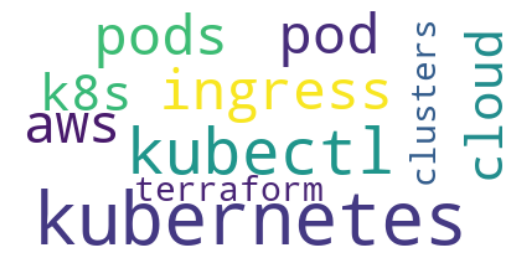

In [31]:
# Display representative terms for one topic.
# Change topic_id to inspect another topic.
adr_topic_model.show_wordcloud(topic_id=3)

In [32]:
# New documents to predict
new_doc = """Date: 2017-07-25 Accepted Verify have a number of pre-existing (closed source) libraries at various levels of abstraction for handling SAML behaviour. By depending on these we can benefit from all the work that's already been done making these easy to use and secure by default. There's a plan in the medium term to open source a lot of these libraries. By depending on as few of them as possible we should be able to call the verify-service-provider "fully open" sooner. Some of the libraries at higher levels of abstraction are of questionable value - although they make it easy to be consistent with the rest of verify they abstract away the exact nature of the SAML which makes the code hard to read. Good libraries that we should use for now: saml-serialisers ida-saml-extensions saml-security saml-metadata-bindings Libraries we think we should ignore hub-saml We may have to inline some bits of e.g. hub-saml, or reimplement them differently.""" 
result = adr_topic_model.predict(new_doc, as_dict=False)

color_name_markdown = '<span style="color: orange;">' + new_doc + '</span>'
display(Markdown(color_name_markdown))

print(f"Topics: {result.topics}") # e.g., [0, 1]
print(f"Probabilities: {result.probabilities}") # e.g., [0.9, 0.8]
print("-----")
threshold = 0.1
labels = topic_model.get_topic_info()['CustomName'].tolist()
for topic, prob in zip(result.topics, result.probabilities):
    if prob > threshold:
        print(f"Topic {topic}: {result.keybert_representation}")
        print(f"Label: {result.openai_representation}")
        print(f"{result.keywords}")
    print("-----")

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

2026-06-20 09:00:06,390 - BERTopic - Predicting topic assignments through cosine similarity of topic and document embeddings.


<span style="color: orange;">Date: 2017-07-25 Accepted Verify have a number of pre-existing (closed source) libraries at various levels of abstraction for handling SAML behaviour. By depending on these we can benefit from all the work that's already been done making these easy to use and secure by default. There's a plan in the medium term to open source a lot of these libraries. By depending on as few of them as possible we should be able to call the verify-service-provider "fully open" sooner. Some of the libraries at higher levels of abstraction are of questionable value - although they make it easy to be consistent with the rest of verify they abstract away the exact nature of the SAML which makes the code hard to read. Good libraries that we should use for now: saml-serialisers ida-saml-extensions saml-security saml-metadata-bindings Libraries we think we should ignore hub-saml We may have to inline some bits of e.g. hub-saml, or reimplement them differently.</span>

Topics: [19]
Probabilities: [0.7367282509803772]
-----
Topic 19: ['18_cassandramessageidmapper_cassandramessagemapper_imapuidtable_messageidtable']
Label: ['Cassandra Mailbox Data Model and Consistency Challenges']
[['authnrequests', 'authnrequest', 'saml', 'saml2', 'verifiable', 'validate', 'subjectconfirmationdata', 'authenticity', 'assertions', 'credentials']]
-----


## 8. Evaluate topic quality

We report two complementary metrics:

- **Topic coherence:** semantic relatedness among the representative words of each
  topic.
- **Topic diversity:** uniqueness of representative words across topics.

Higher values are generally preferable, but these metrics should be interpreted
together with manual inspection because they do not fully capture architectural
relevance or human interpretability. Perplexity is not computed because BERTopic is
embedding-based rather than a probabilistic generative model.

In [33]:
# Compute the two topic-quality metrics reported in the companion paper.
# Interpret coherence and diversity jointly.
print("Coherence =", adr_topic_model.compute_topic_coherence())
print("Diversity =", adr_topic_model.compute_topic_diversity())

Coherence = 0.36556718549015643
Diversity = 0.9958907402293208


---

## 9. Apply the model to the complete curated corpus

This stage predicts one dominant topic for every ADR in every valid project and writes
the results to `../results/all_projects-topics.json`.

> **Runtime note:** Full-corpus inference can take several minutes. If the output file
> already exists, the expensive inference step is skipped.

## 9. Full-corpus topic assignment

In [34]:
# Full-corpus topic assignments are written to this JSON file.
ALL_PROJECTS_RESULTS = './results/all_projects-topics.json' 

In [35]:
relative_path = os.path.join('..', ALL_PROJECTS_RESULTS)

all_results = []
if not os.path.isfile(relative_path):
    print(f"Inferring topics for ADRs from {len(valid_projects)} valid projects")

    for org, project in tqdm(valid_projects, desc="Processing organizations/projects"):
        adrs_to_process = utils.get_documents_by_key(
            (org, project),
            dict_adrs,
            field='raw',
        )
        results = adr_topic_model.predict_batch(
            adrs_to_process,
            organization=org,
            project=project,
            as_dict=True,
            multiple_topics=False,
        )
        all_results.extend(results)

    print("Saving JSON results to", relative_path)
    ADRTopicModel.save_results(all_results, relative_path)
else:
    # Load cached results so the summary cell reports the correct count.
    with open(relative_path, 'r', encoding='utf-8') as file:
        all_results = json.load(file)
    print("Loaded cached results from", relative_path)

print("End.")

Loaded cached results from ..\./results/all_projects-topics.json
End.


In [36]:
# Confirm how many ADR-level topic assignments are available.
print(len(all_results), "ADRs processed.")

4316 ADRs processed.


---

## 10. Expected artifacts and next steps

After completing the notebook, the main reusable artifacts are:

- the persisted BERTopic model under `saved_topicmodel/`;
- topic assignments for the complete corpus in
  `../results/all_projects-topics.json`;
- topic-quality metrics and visualizations displayed in this notebook.

The generated topic assignments can be combined with the outputs of the classification
and MADR-checking notebooks in the downstream analysis workflow.